# Snow-Underlay: cross-season image matching for snow-plough autonomy

**A submission to SoTA Commission I — Minimal-Shot Autonomy.**

Self-driving systems train on dry roads. Snow ploughs operate in the regime that data deliberately excludes. This notebook demonstrates a perception module that handles the gap by *not learning the gap at all* — instead, every snowy frame is matched against a clear-season prior of the same location, and the road location is transferred geometrically.

**Minimal-shot integrity guarantee.** Every model in this pipeline was trained on imagery that contains *no snow*. Snow appears only at inference time, as the runtime input. We never fine-tune on snowy data, never expose a model to a snowy frame during training, and never claim the model has learned anything about snow.

| Component | Pretrained on | Snow in training? |
| --- | --- | --- |
| DISK feature extractor | MegaDepth | No |
| LightGlue matcher | MegaDepth | No |
| Segformer-B0 road segmenter | Cityscapes | No |

## 1. The pipeline at a glance

```
[snowy query] ─┐
               ├─> DISK + LightGlue ──> correspondences
[clear prior] ─┤                            │
               │                            └─> RANSAC homography (ground-plane biased)
               │                                       │
[clear prior] ─┴─> Segformer (Cityscapes) ─> road mask │
                                                       └─> warpPerspective ─> road on snow
```

In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import json
import cv2, numpy as np, matplotlib.pyplot as plt
import sys; sys.path.insert(0, str(Path('..').resolve()))
from src.matching import Matcher, draw_matches
from src.homography import estimate as estimate_homography
from src.segmentation import RoadSegmenter
from src.overlay import warp_mask, alpha_blend, three_panel_figure
from src.pipeline import run_pair, _load_rgb, _resize_to

PAIRS = Path('../data/pairs')
OUT = Path('../outputs/heroes')

## 2. Pull paired imagery from Mapillary

Mapillary is a community open-imagery platform. We treat it as the open *substrate* for both the snowy query frames and the clear prior frames. The two are pulled independently — there is no joint capture, no shared sensor, no implicit coupling. They are two photos of the same place, taken months apart, by different contributors, at slightly different angles.

The fetcher (`data/fetch_mapillary.py`):
1. Pulls all images in a bounding box around known-snowy regions (Östersund, Tromsø, Rovaniemi, Kiruna, Anchorage, Yellowknife).
2. Splits them by capture month into a winter set (Dec–Mar) and a summer set (May–Sep).
3. For each winter image, finds the nearest summer image within 5 m and ±20° heading.
4. Saves the pair under `data/pairs/<region>__<id1>__<id2>/{snow.jpg, clear.jpg, meta.json}`.

Run once: `MAPILLARY_TOKEN=... uv run python -m data.fetch_mapillary`

In [2]:
available = sorted(p for p in PAIRS.iterdir() if p.is_dir()) if PAIRS.exists() else []
print(f'{len(available)} pairs available')
for p in available[:8]:
    meta = json.loads((p / 'meta.json').read_text())
    print(f"  {p.name}  dist={meta['distance_m']}m  Δheading={meta['heading_delta_deg']}°")

39 pairs available
  kiruna_se__1017923352076408__331695611727772  dist=0.29m  Δheading=0.79°
  kiruna_se__1132166577296546__430202249821980  dist=0.06m  Δheading=5.98°
  kiruna_se__146117464191250__473098661877951  dist=0.23m  Δheading=7.22°
  kiruna_se__173943764513956__2572648156371424  dist=0.21m  Δheading=4.33°
  kiruna_se__191430299489835__1372566446455224  dist=0.31m  Δheading=12.34°
  kiruna_se__294581095485214__169070348464227  dist=0.31m  Δheading=17.4°
  kiruna_se__301760808219031__813395426217471  dist=0.25m  Δheading=17.45°
  kiruna_se__474352240535542__372889160790900  dist=0.21m  Δheading=12.21°


## 3. End-to-end on a single pair

Pick the first available pair and walk through the steps explicitly.

using pair: kiruna_se__173943764513956__2572648156371424


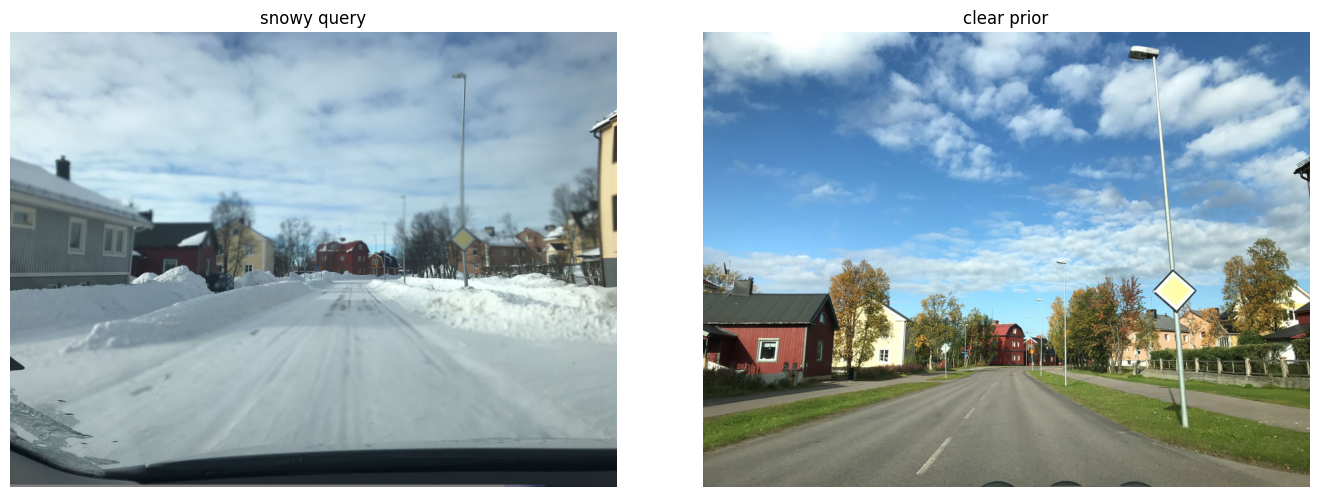

In [3]:
# Use a deterministic hero pair (Kiruna, red Falun-style houses, road fully buried in snow).
# Falls back to the first available pair if the hero is missing.
HERO = 'kiruna_se__173943764513956__2572648156371424'
pair = next((p for p in available if p.name == HERO), available[0] if available else None)
assert pair is not None, 'No pairs available — run the fetcher first.'
print(f'using pair: {pair.name}')
snow = _resize_to(_load_rgb(pair / 'snow.jpg'))
clear = _resize_to(_load_rgb(pair / 'clear.jpg'))
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].imshow(snow); axs[0].set_title('snowy query'); axs[0].axis('off')
axs[1].imshow(clear); axs[1].set_title('clear prior'); axs[1].axis('off')
plt.tight_layout(); plt.show()

In [4]:
matcher = Matcher()
result = matcher.match(snow, clear)
print(f'{len(result.kpts0)} matches')

Loaded LightGlue model


455 matches


inliers: 47 / 455    ground-plane bias: True


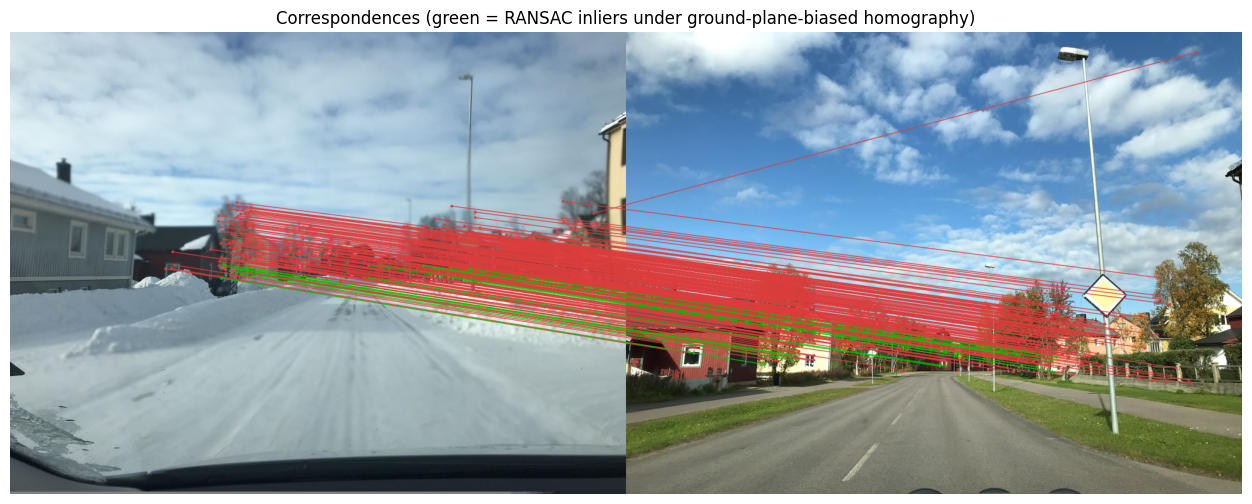

In [5]:
homo = estimate_homography(result, snow.shape[:2], clear.shape[:2])
print(f'inliers: {homo.n_inliers} / {len(result.kpts0)}    ground-plane bias: {homo.used_ground_plane_restriction}')
viz = draw_matches(snow, clear, result, inlier_mask=homo.inlier_mask)
plt.figure(figsize=(16, 6)); plt.imshow(viz); plt.axis('off')
plt.title('Correspondences (green = RANSAC inliers under ground-plane-biased homography)'); plt.show()

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

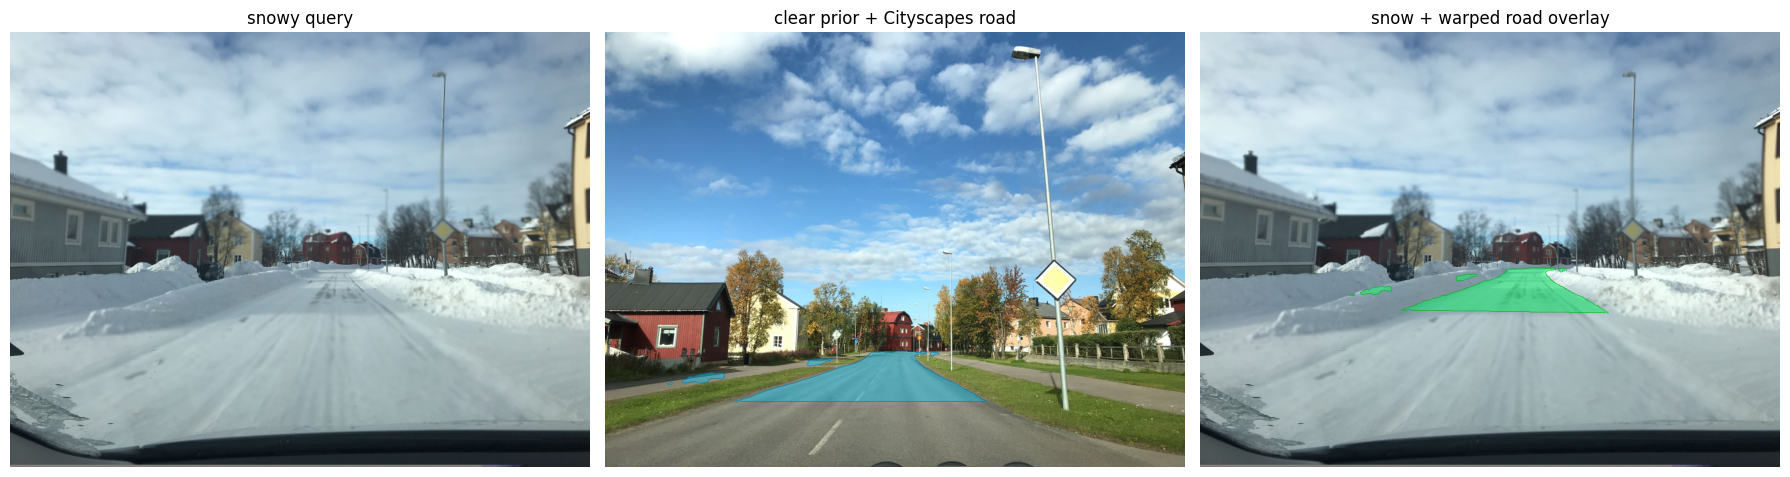

In [6]:
segmenter = RoadSegmenter()
road_clear = segmenter.segment_road(clear)
H_inv = np.linalg.inv(homo.H)
road_snow = warp_mask(road_clear, H_inv, snow.shape[:2])
snow_overlay = alpha_blend(snow, road_snow)
fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(snow); axs[0].set_title('snowy query')
axs[1].imshow(alpha_blend(clear, road_clear, color=(0,200,255), alpha=0.4)); axs[1].set_title('clear prior + Cityscapes road')
axs[2].imshow(snow_overlay); axs[2].set_title('snow + warped road overlay')
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()

## 4. The naive baseline that motivates the approach

What if we skipped the cross-season step and just ran the same Cityscapes segmenter directly on the snowy frame? The model has never seen snow during training. The expected failure mode is fragmented, shifted, or missing road predictions.

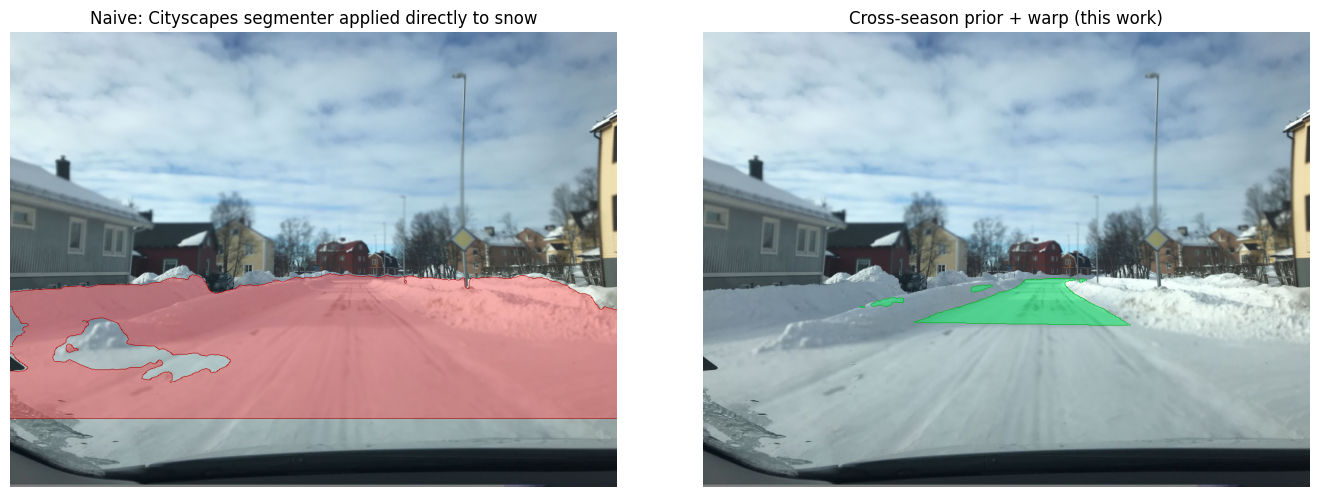

naive road coverage: 27.84%    cross-season road coverage: 2.02%


In [7]:
road_snow_naive = segmenter.segment_road(snow)
naive_overlay = alpha_blend(snow, road_snow_naive, color=(255, 80, 80), alpha=0.45)
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].imshow(naive_overlay); axs[0].set_title('Naive: Cityscapes segmenter applied directly to snow')
axs[1].imshow(snow_overlay); axs[1].set_title('Cross-season prior + warp (this work)')
for ax in axs: ax.axis('off')
plt.tight_layout(); plt.show()
print(f'naive road coverage: {road_snow_naive.mean():.2%}    cross-season road coverage: {road_snow.mean():.2%}')

## 5. Sweep over all pairs

`src/pipeline.run_all` applies the same procedure to every pair under `data/pairs/`. Outputs are cached under `outputs/heroes/`.

In [8]:
from src.pipeline import run_all
results = run_all(pairs_dir=PAIRS, out_dir=OUT)

Loaded LightGlue model


  [reject] kiruna_se__1017923352076408__331695611727772: matches=7 inliers=0 (ground-plane=False)


  [reject] kiruna_se__1132166577296546__430202249821980: matches=4 inliers=0 (ground-plane=False)


Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

  [reject] kiruna_se__146117464191250__473098661877951: matches=28 inliers=7 (ground-plane=False)


...

  [ACCEPT] rovaniemi_fi__26341928928771658__1533316530937158: matches=251 inliers=98 (ground-plane=True)


  [ACCEPT] rovaniemi_fi__26582409111354697__510356658196654: matches=440 inliers=101 (ground-plane=True)


  [ACCEPT] rovaniemi_fi__516661399688105__513584009819912: matches=166 inliers=41 (ground-plane=True)


  [reject] tromso_no__2025282437947319__1387468618972222: matches=3 inliers=0 (ground-plane=False)


  [reject] tromso_no__667569105696238__1294873282194097: matches=2 inliers=0 (ground-plane=False)


## 6. Honest failure case

Heavy snow (frosted trees, low contrast, fully white ground) starves the matcher of usable structure. The system fails *gracefully* — low inlier counts trigger no overlay rather than a confidently wrong one. Below is one such case from the run.

In [9]:
if results:
    worst = min(results, key=lambda r: r.n_inliers)
    print(f'worst pair: {worst.pair_id}  inliers={worst.n_inliers}')
    if worst.figure_path and Path(worst.figure_path).exists():
        plt.figure(figsize=(16, 6)); plt.imshow(plt.imread(worst.figure_path)); plt.axis('off'); plt.show()

worst pair: kiruna_se__1017923352076408__331695611727772  inliers=0


## 7. What this notebook does *not* claim

- That this replaces lidar / depth sensing on a real plough. The output is a 2D road prior, not a 3D drivable surface estimate.
- That homography is geometrically correct everywhere. It is exact only on the ground plane; we bias toward that and rely on the warp being approximately right.
- That the matcher will work in arbitrary blizzard conditions. It will not. The minimum-viable contribution is showing that, *without any snowy training data*, the system can recover the road in moderate-snow scenes by leaning entirely on a clear-season prior.